# SmartBiz AI: Exploratory Data Analysis
## Weekly product demand in the UCI Online Retail dataset

**Capstone Two - Step 3: EDA**  
**Author:** Jacob Paul  
**Business objective:** Understand the structure and drivers of weekly product demand before building a forecasting model for small retail businesses.

### Questions addressed

1. What does demand look like at the intended forecasting grain: product-week?
2. How does demand change over time, across calendar periods, products, and markets?
3. How sparse, skewed, and concentrated is weekly product demand?
4. Is fourth-quarter demand materially different from demand during the rest of the year?
5. Which features should move forward to modeling, and which would cause leakage?

The notebook is intentionally limited to exploration and feature recommendations. Model fitting belongs in the later modeling notebook.


## 1. Setup and reproducibility

The source workbook is loaded from the repository's `data` directory. No machine-specific absolute path or network download is required.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

candidate_paths = [
    Path('../data/Online Retail.xlsx'),  # when run from notebooks/
    Path('data/Online Retail.xlsx'),     # when run from repository root
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Place Online Retail.xlsx in the repository data/ directory.')

print(f'Data source: {DATA_PATH.resolve()}')


Data source: /workspace/scratch/6778bacedd1c/retail-demand-forecasting-capstone/data/Online Retail.xlsx


## 2. Load and profile the raw transaction data

The dataset contains invoice-line transactions. `Quantity` is not yet the modeling target; the final target will be total units sold for a product during a week.


In [2]:
raw = pd.read_excel(DATA_PATH, engine='openpyxl')
raw_count = len(raw)

print(f'Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
print(f'Date range: {raw["InvoiceDate"].min()} to {raw["InvoiceDate"].max()}')
display(raw.head())


Raw shape: 541,909 rows x 8 columns
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55   17,850.00  United Kingdom  
1 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom  
2 2010-12-01 08:26:00       2.75   17,850.00  United Kingdom  
3 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom  
4 2010-12-01 08:26:00       3.39   17,850.00  United Kingdom  

In [3]:
data_dictionary = pd.DataFrame({
    'field': ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
              'UnitPrice', 'CustomerID', 'Country'],
    'role': ['invoice identifier', 'product identifier', 'product label',
             'units on invoice line', 'transaction timestamp', 'price per unit',
             'customer identifier', 'customer country'],
    'modeling_status': ['audit only', 'grouping key', 'reporting only', 'source of target',
                        'time key', 'candidate only if known before forecast',
                        'not required for demand model', 'exploratory/contextual'],
})
display(data_dictionary)

profile = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'non_null': raw.notna().sum(),
    'missing': raw.isna().sum(),
    'missing_pct': raw.isna().mean().mul(100),
    'unique': raw.nunique(dropna=True),
})
display(profile)


         field                   role                          modeling_status
0    InvoiceNo     invoice identifier                               audit only
1    StockCode     product identifier                             grouping key
2  Description          product label                           reporting only
3     Quantity  units on invoice line                         source of target
4  InvoiceDate  transaction timestamp                                 time key
5    UnitPrice         price per unit  candidate only if known before forecast
6   CustomerID    customer identifier            not required for demand model
7      Country       customer country                   exploratory/contextual

                      dtype  non_null  missing  missing_pct  unique
InvoiceNo            object    541909        0         0.00   25900
StockCode            object    541909        0         0.00    4070
Description          object    540455     1454         0.27    4223
Quantity              int64    541909        0         0.00     722
InvoiceDate  datetime64[ns]    541909        0         0.00   23260
UnitPrice           float64    541909        0         0.00    1630
CustomerID          float64    406829   135080        24.93    4372
Country              object    541909        0         0.00      38

### Initial quality observations

- Missing `CustomerID` values are retained because customer identity is not required to forecast warehouse-level product demand. Customer-level analyses must use a non-null subset.
- Cancelled/adjustment invoices, non-positive quantities, non-positive prices, and exact duplicates do not represent ordinary fulfilled product demand.
- The proposal's earlier suggestion to remove missing-customer rows is superseded by the demand-focused rule above; retaining them avoids discarding valid demand.


## 3. Reproduce the wrangling rules and audit retention

Rows are filtered sequentially so every removal is traceable. Non-merchandise stock codes such as postage, bank charges, samples, and manual adjustments are excluded because they are not inventory demand.


In [4]:
df = raw.copy()
df['InvoiceNo'] = df['InvoiceNo'].astype(str).str.strip()
df['StockCode'] = df['StockCode'].astype(str).str.strip()

audit_rows = []
def log_step(step, before, after):
    audit_rows.append({'step': step, 'rows_removed': before - after, 'rows_remaining': after})

before = len(df)
df = df.loc[~df['InvoiceNo'].str.startswith(('C', 'A'))].copy()
log_step('Remove cancellation/adjustment invoices', before, len(df))

before = len(df)
df = df.loc[df['Quantity'] > 0].copy()
log_step('Keep positive quantity', before, len(df))

before = len(df)
df = df.loc[df['UnitPrice'] > 0].copy()
log_step('Keep positive unit price', before, len(df))

before = len(df)
df = df.drop_duplicates().copy()
log_step('Remove exact duplicate rows', before, len(df))

non_merchandise = ~df['StockCode'].str.contains(r'\d', regex=True)
special_code_summary = (
    df.loc[non_merchandise]
      .groupby('StockCode')
      .agg(rows=('InvoiceNo', 'size'),
           description=('Description', lambda s: s.mode().iat[0] if not s.mode().empty else 'Unknown'))
      .sort_values('rows', ascending=False)
)

before = len(df)
df = df.loc[~non_merchandise].copy()
log_step('Remove non-merchandise stock codes', before, len(df))

audit = pd.DataFrame(audit_rows)
audit['retention_pct_of_raw'] = audit['rows_remaining'].div(raw_count).mul(100)
display(audit)
display(special_code_summary)
print(f'Final transaction-level retention: {len(df) / raw_count:.1%}')
print(f'Missing CustomerID rows retained: {df["CustomerID"].isna().sum():,}')


Final transaction-level retention: 96.5%
Missing CustomerID rows retained: 131,402


                                      step  rows_removed  rows_remaining  \
0  Remove cancellation/adjustment invoices          9291          532618   
1                   Keep positive quantity          1336          531282   
2                 Keep positive unit price          1179          530103   
3              Remove exact duplicate rows          5226          524877   
4       Remove non-merchandise stock codes          2192          522685   

   retention_pct_of_raw  
0                 98.29  
1                 98.04  
2                 97.82  
3                 96.86  
4                 96.45  

              rows                 description
StockCode                                     
POST          1126                     POSTAGE
DOT            706              DOTCOM POSTAGE
M              316                      Manual
DCGSSGIRL       13             GIRLS PARTY BAG
BANK CHARGES    12                Bank Charges
DCGSSBOY        11              BOYS PARTY BAG
PADS             3  PADS TO MATCH ALL CUSHIONS
AMAZONFEE        2                  AMAZON FEE
S                2                     SAMPLES
m                1                      Manual

In [5]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['WeekStart'] = df['InvoiceDate'].dt.to_period('W-SUN').dt.start_time
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

summary = pd.Series({
    'clean transaction rows': len(df),
    'unique invoices': df['InvoiceNo'].nunique(),
    'unique merchandise products': df['StockCode'].nunique(),
    'unique countries': df['Country'].nunique(),
    'total units': df['Quantity'].sum(),
    'total revenue': df['Revenue'].sum(),
})
display(summary.to_frame('value'))


                                    value
clean transaction rows         522,685.00
unique invoices                 19,776.00
unique merchandise products      3,911.00
unique countries                    38.00
total units                  5,561,465.00
total revenue               10,254,661.15

## 4. Transaction-level distributions and outliers

Quantity, price, and revenue are expected to be right-skewed because retail includes both ordinary consumer orders and legitimate bulk purchases. The log-scaled views reveal the main distribution without deleting high-volume demand.


               count  mean    std  min  50%   75%   90%   95%    99%  99.9%  \
Quantity  522,685.00 10.64 156.57 1.00 4.00 12.00 24.00 30.00 100.00 456.00   
UnitPrice 522,685.00  3.29   4.46 0.04 2.08  4.13  7.65  9.95  16.63  39.95   
Revenue   522,685.00 19.62 269.90 0.06 9.90 17.70 31.80 59.40 179.00 750.00   

                 max  
Quantity   80,995.00  
UnitPrice     649.50  
Revenue   168,469.60  

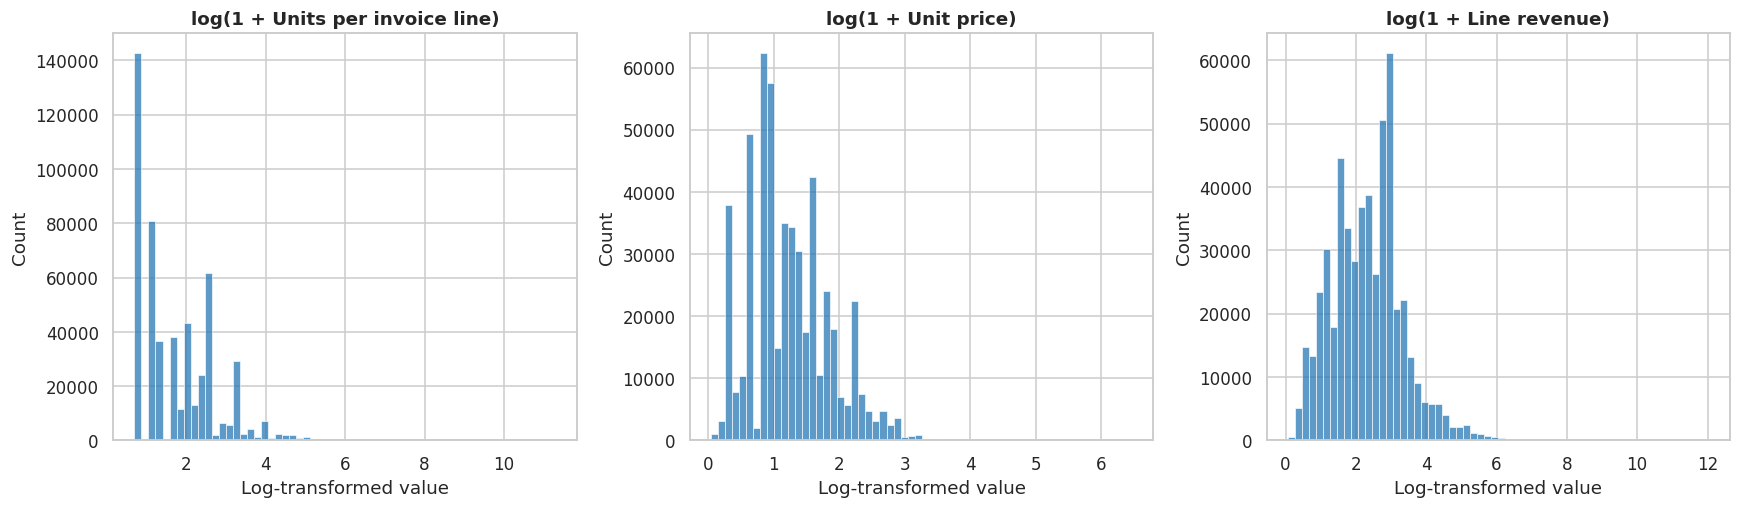

In [6]:
distribution_summary = df[['Quantity', 'UnitPrice', 'Revenue']].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
).T
display(distribution_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, col, label in zip(
    axes,
    ['Quantity', 'UnitPrice', 'Revenue'],
    ['Units per invoice line', 'Unit price', 'Line revenue'],
):
    sns.histplot(np.log1p(df[col]), bins=60, ax=ax, color='#2878B5')
    ax.set_title(f'log(1 + {label})')
    ax.set_xlabel('Log-transformed value')
plt.tight_layout()
plt.show()


**Interpretation.** All three measures have long right tails. These extremes should be investigated, but indiscriminate deletion would erase real bulk demand—the very demand an inventory system must anticipate. For modeling, compare raw and `log1p` targets, report MAE as the primary business metric, and use robust sensitivity checks or carefully learned caps based only on training data.


## 5. Build the product-week analytical table

The first and last calendar weeks are incomplete and are excluded. Products require at least four observed selling weeks, matching the proposal. Within each product's observed lifetime, missing transaction weeks are explicitly filled with zero units. This prevents survivorship bias from analyzing only weeks in which a product sold.


In [7]:
calendar_weeks = np.sort(df['WeekStart'].unique())
incomplete_boundary_weeks = [pd.Timestamp(calendar_weeks[0]), pd.Timestamp(calendar_weeks[-1])]
analysis_transactions = df.loc[~df['WeekStart'].isin(incomplete_boundary_weeks)].copy()

observed_weekly = (
    analysis_transactions
    .groupby(['StockCode', 'WeekStart'], as_index=False)
    .agg(
        UnitsSold=('Quantity', 'sum'),
        Revenue=('Revenue', 'sum'),
        Transactions=('InvoiceNo', 'nunique'),
        MedianUnitPrice=('UnitPrice', 'median'),
        Description=('Description', lambda s: s.mode().iat[0] if not s.mode().empty else 'Unknown'),
    )
)

selling_weeks = observed_weekly.groupby('StockCode')['WeekStart'].nunique()
eligible_products = selling_weeks.loc[selling_weeks >= 4].index
observed_weekly = observed_weekly.loc[observed_weekly['StockCode'].isin(eligible_products)].copy()

panel_parts = []
for stock_code, product in observed_weekly.groupby('StockCode', sort=False):
    product = product.sort_values('WeekStart')
    product_index = pd.date_range(product['WeekStart'].min(), product['WeekStart'].max(), freq='W-MON')
    completed = product.set_index('WeekStart').reindex(product_index)
    completed.index.name = 'WeekStart'
    completed['StockCode'] = stock_code
    completed['UnitsSold'] = completed['UnitsSold'].fillna(0)
    completed['Revenue'] = completed['Revenue'].fillna(0)
    completed['Transactions'] = completed['Transactions'].fillna(0)
    completed['MedianUnitPrice'] = completed['MedianUnitPrice'].ffill().bfill()
    completed['Description'] = completed['Description'].ffill().bfill()
    panel_parts.append(completed.reset_index())

weekly_panel = pd.concat(panel_parts, ignore_index=True)
weekly_panel['Month'] = weekly_panel['WeekStart'].dt.month
weekly_panel['Quarter'] = weekly_panel['WeekStart'].dt.quarter
weekly_panel['IsQ4'] = weekly_panel['Quarter'].eq(4)
weekly_panel['IsZeroDemand'] = weekly_panel['UnitsSold'].eq(0)

print(f'Incomplete boundary weeks excluded: {incomplete_boundary_weeks}')
print(f'Eligible products (>=4 selling weeks): {len(eligible_products):,}')
print(f'Observed product-weeks: {len(observed_weekly):,}')
print(f'Completed product-week panel: {len(weekly_panel):,}')
print(f'Zero-demand share after completion: {weekly_panel["IsZeroDemand"].mean():.1%}')
display(weekly_panel.head())


Incomplete boundary weeks excluded: [Timestamp('2010-11-29 00:00:00'), Timestamp('2011-12-05 00:00:00')]
Eligible products (>=4 selling weeks): 3,450
Observed product-weeks: 96,240
Completed product-week panel: 145,618
Zero-demand share after completion: 33.9%


   WeekStart StockCode  UnitsSold  Revenue  Transactions  MedianUnitPrice  \
0 2010-12-06     10002     138.00   127.02         14.00             0.85   
1 2010-12-13     10002      41.00    38.90          8.00             1.25   
2 2010-12-20     10002       2.00     3.32          1.00             1.66   
3 2010-12-27     10002       0.00     0.00          0.00             1.66   
4 2011-01-03     10002      73.00    62.86          3.00             0.85   

                   Description  Month  Quarter   IsQ4  IsZeroDemand  
0  INFLATABLE POLITICAL GLOBE      12        4   True         False  
1  INFLATABLE POLITICAL GLOBE      12        4   True         False  
2  INFLATABLE POLITICAL GLOBE      12        4   True         False  
3  INFLATABLE POLITICAL GLOBE      12        4   True          True  
4  INFLATABLE POLITICAL GLOBE       1        1  False         False  

       UnitsSold
count 145,618.00
mean       35.82
std       222.84
min         0.00
50%         4.00
75%        26.00
90%        90.00
95%       166.00
99%       457.83
max    74,215.00

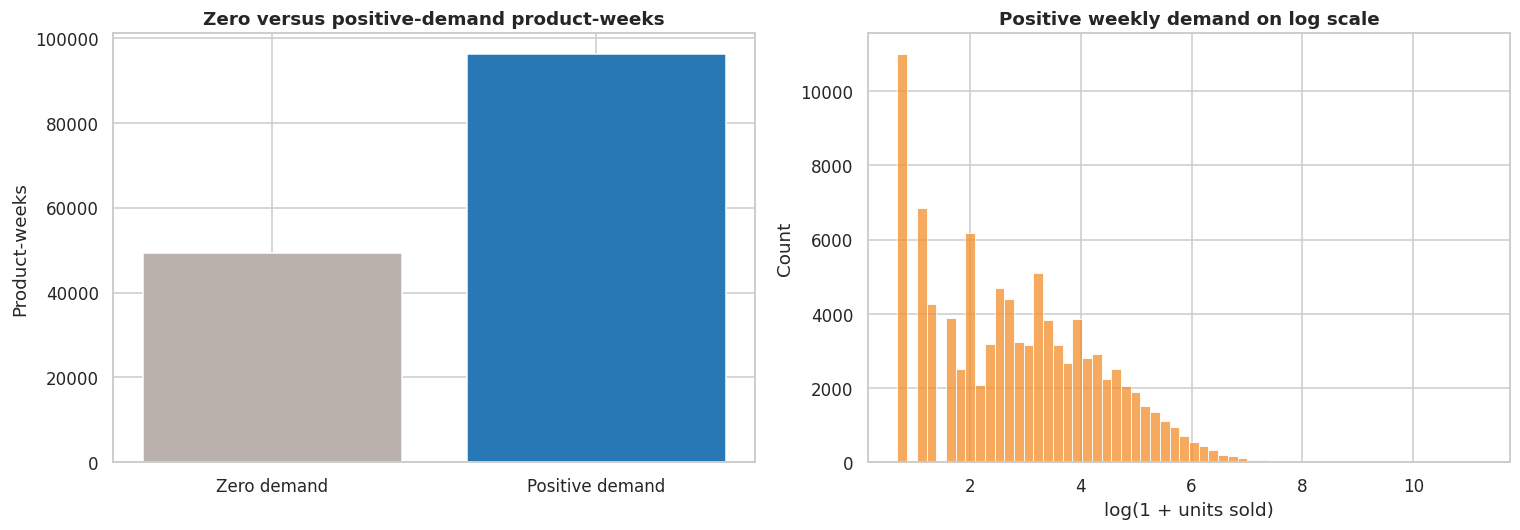

In [8]:
target_summary = weekly_panel['UnitsSold'].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame('UnitsSold')
display(target_summary)

zero_mix = pd.Series({
    'Zero demand': weekly_panel['IsZeroDemand'].sum(),
    'Positive demand': (~weekly_panel['IsZeroDemand']).sum(),
})
positive_demand = weekly_panel.loc[weekly_panel['UnitsSold'] > 0, 'UnitsSold']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(zero_mix.index, zero_mix.values, color=['#BAB0AC', '#2878B5'])
axes[0].set_title('Zero versus positive-demand product-weeks')
axes[0].set_ylabel('Product-weeks')
sns.histplot(np.log1p(positive_demand), bins=60, ax=axes[1], color='#F28E2B')
axes[1].set_title('Positive weekly demand on log scale')
axes[1].set_xlabel('log(1 + units sold)')
plt.tight_layout()
plt.show()


**Target insight.** Weekly product demand is zero-inflated and extremely right-skewed. The median is far below the mean, and rare product-weeks contain very large bulk orders. A single global RMSE would be dominated by these extremes, so later evaluation should report MAE, RMSE, and performance by demand-volume segment. A naive per-product forecast is a more meaningful benchmark than a single global mean.


## 6. Demand over time

Weekly totals reveal trend, seasonality, closures, and changes in the number of products generating demand.


    WeekStart  UnitsSold    Revenue  ActiveProducts  EligibleProducts
49 2011-11-14 184,746.00 373,203.30            2379              2702
48 2011-11-07 182,129.00 357,708.46            2313              2789
43 2011-10-03 170,837.00 310,984.68            2125              2923
41 2011-09-19 169,356.00 328,812.78            2142              2927
47 2011-10-31 158,062.00 292,457.02            2302              2850
51 2011-11-28 154,404.00 305,407.69            2261              2261
50 2011-11-21 154,299.00 301,666.42            2344              2572
45 2011-10-17 152,258.00 264,414.45            2200              2925

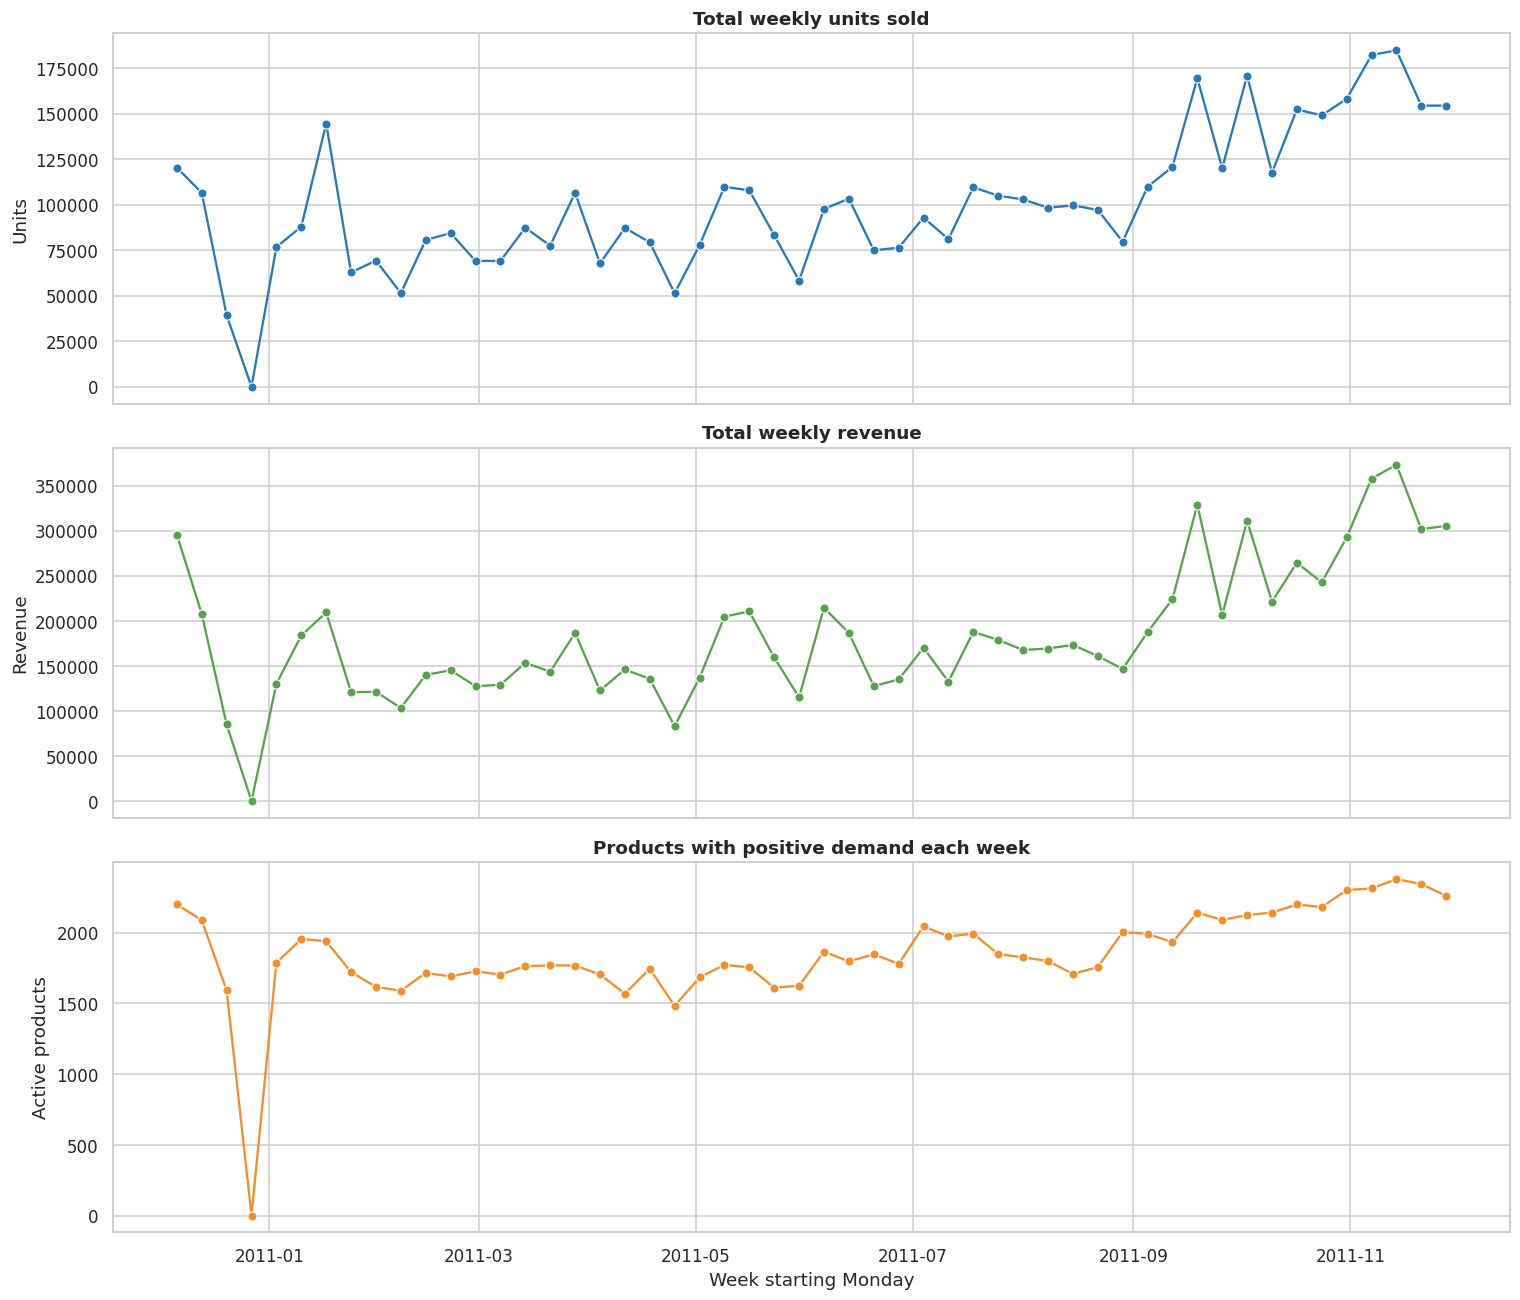

In [9]:
weekly_business = (
    weekly_panel.groupby('WeekStart', as_index=False)
    .agg(
        UnitsSold=('UnitsSold', 'sum'),
        Revenue=('Revenue', 'sum'),
        ActiveProducts=('UnitsSold', lambda s: s.gt(0).sum()),
        EligibleProducts=('StockCode', 'size'),
    )
)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
sns.lineplot(data=weekly_business, x='WeekStart', y='UnitsSold', marker='o', ax=axes[0], color='#2878B5')
axes[0].set_title('Total weekly units sold')
axes[0].set_ylabel('Units')
sns.lineplot(data=weekly_business, x='WeekStart', y='Revenue', marker='o', ax=axes[1], color='#59A14F')
axes[1].set_title('Total weekly revenue')
axes[1].set_ylabel('Revenue')
sns.lineplot(data=weekly_business, x='WeekStart', y='ActiveProducts', marker='o', ax=axes[2], color='#F28E2B')
axes[2].set_title('Products with positive demand each week')
axes[2].set_ylabel('Active products')
axes[2].set_xlabel('Week starting Monday')
plt.tight_layout()
plt.show()

display(weekly_business.nlargest(8, 'UnitsSold'))


**Interpretation.** Demand accelerates strongly in September-November, consistent with holiday-season stocking and shopping. The zero-demand week around the late-December closure is a real operational pattern rather than missing data. The first and last source weeks were excluded because they were incomplete. With only one year of history, annual seasonality cannot be validated across multiple cycles.


      Month  UnitsSold      Revenue  Orders
0   2011-01     386745   670,639.46    1081
1   2011-02     282630   508,065.09    1093
2   2011-03     376160   690,466.82    1440
3   2011-04     307661   515,863.08    1235
4   2011-05     394656   740,436.14    1668
5   2011-06     388141   738,233.99    1525
6   2011-07     399275   688,728.12    1452
7   2011-08     420703   724,688.42    1340
8   2011-09     568717 1,029,238.80    1819
9   2011-10     619611 1,104,027.63    2005
10  2011-11     746974 1,453,262.69    2751

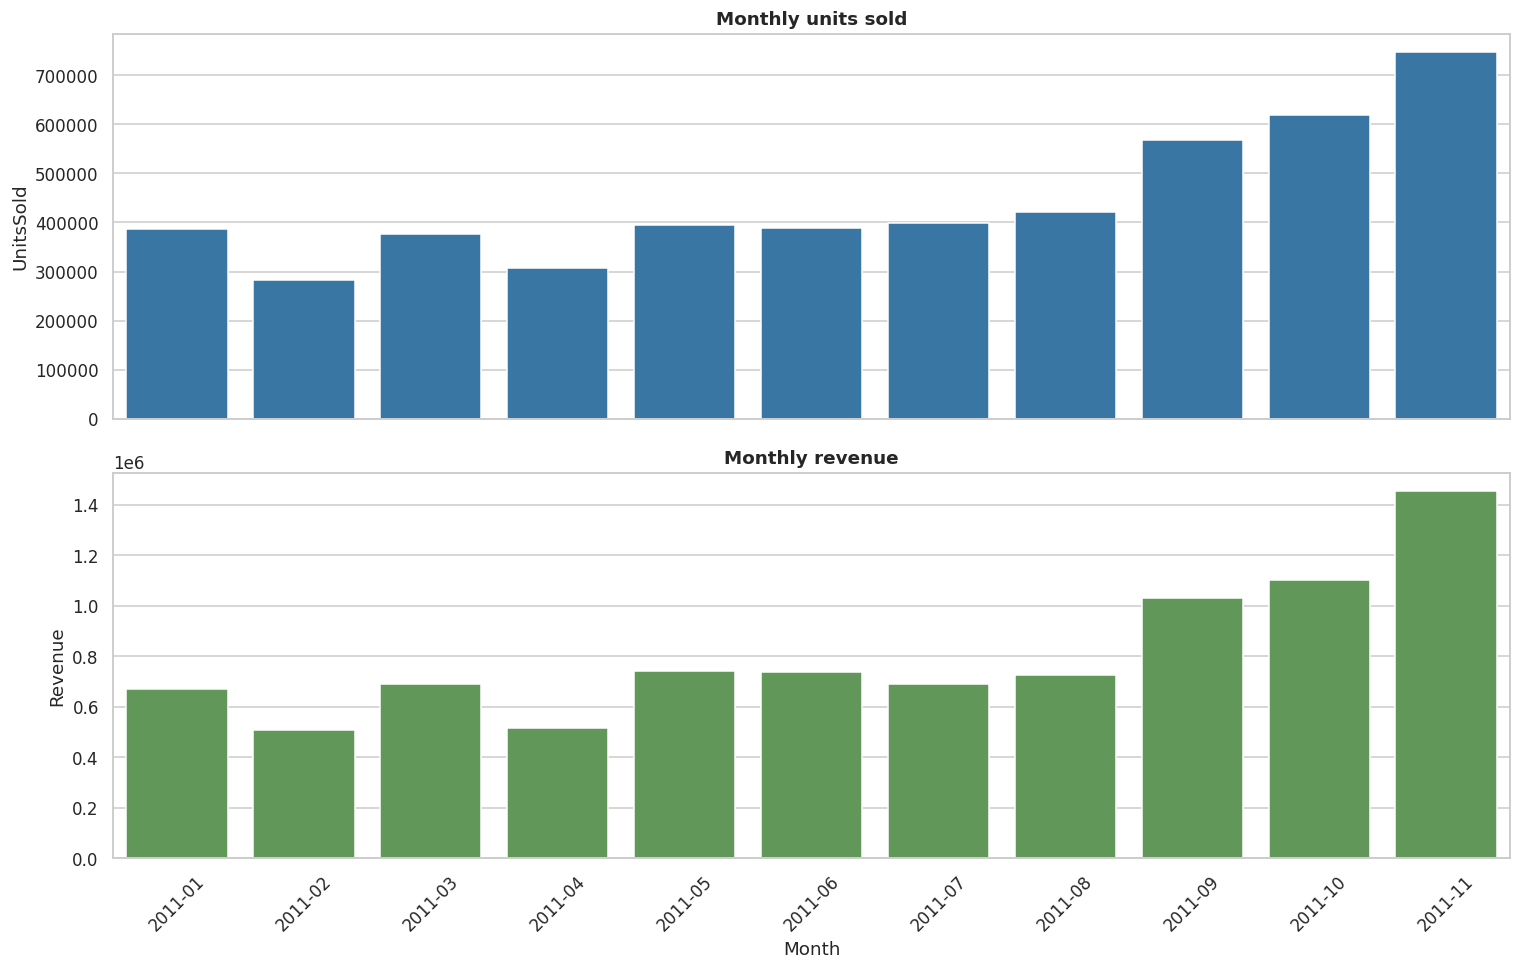

In [10]:
complete_month_transactions = analysis_transactions.loc[
    analysis_transactions['InvoiceDate'].dt.to_period('M').between(
        pd.Period('2011-01', freq='M'), pd.Period('2011-11', freq='M')
    )
].copy()
monthly = (
    complete_month_transactions.groupby('Month', as_index=False)
    .agg(UnitsSold=('Quantity', 'sum'), Revenue=('Revenue', 'sum'), Orders=('InvoiceNo', 'nunique'))
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
sns.barplot(data=monthly, x='Month', y='UnitsSold', ax=axes[0], color='#2878B5')
axes[0].set_title('Monthly units sold')
axes[0].set_xlabel('')
sns.barplot(data=monthly, x='Month', y='Revenue', ax=axes[1], color='#59A14F')
axes[1].set_title('Monthly revenue')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
display(monthly)


**Interpretation.** Units, revenue, and order volume rise markedly in the autumn and peak in November. The partial calendar months December 2010 and December 2011 are intentionally excluded; comparing either with complete months would create a misleading pattern.


## 7. Calendar patterns

Transaction-day patterns are descriptive rather than directly usable as weekly predictors. They help explain operations and motivate calendar and holiday features.


   DayOfWeek  UnitsSold      Revenue  Orders
1     Monday     825322 1,604,111.94    2951
4    Tuesday    1079685 2,030,947.47    3397
5  Wednesday     954124 1,653,229.05    3435
3   Thursday    1139163 2,008,529.25    3948
0     Friday     779196 1,525,370.83    2997
2     Sunday     448889   767,902.83    2115

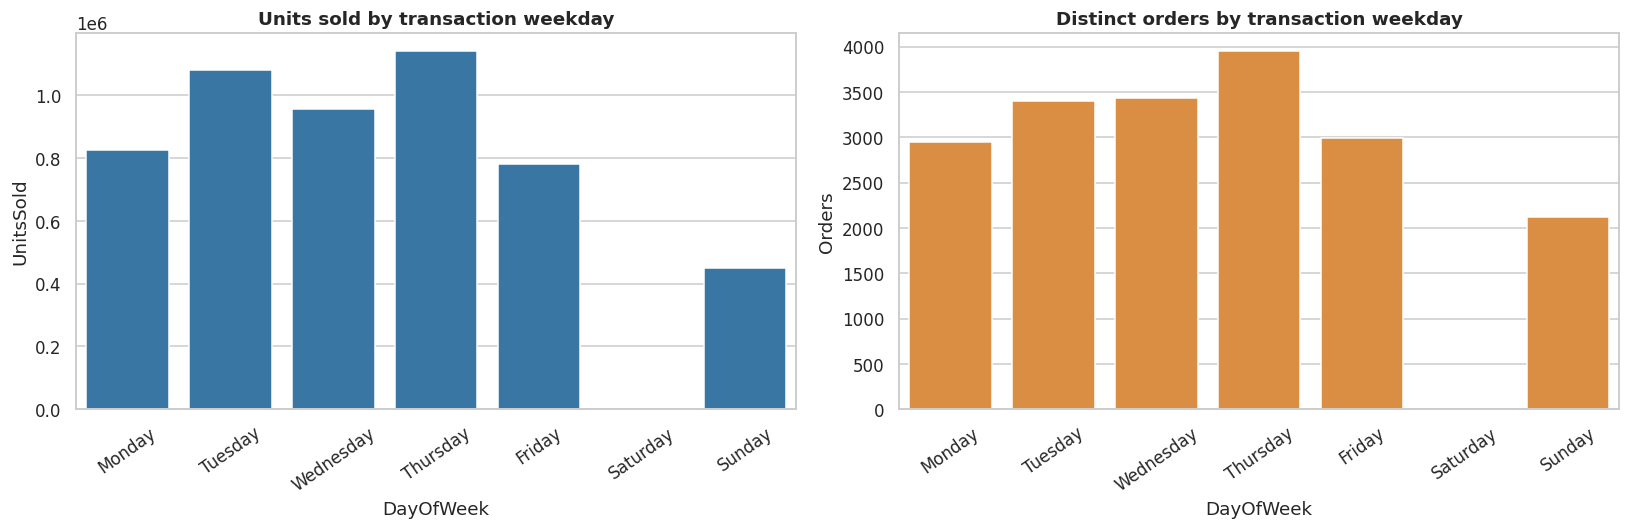

In [11]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday = (
    analysis_transactions.groupby('DayOfWeek', as_index=False)
    .agg(UnitsSold=('Quantity', 'sum'), Revenue=('Revenue', 'sum'), Orders=('InvoiceNo', 'nunique'))
)
weekday['DayOfWeek'] = pd.Categorical(weekday['DayOfWeek'], categories=day_order, ordered=True)
weekday = weekday.sort_values('DayOfWeek')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=weekday, x='DayOfWeek', y='UnitsSold', ax=axes[0], color='#2878B5')
axes[0].set_title('Units sold by transaction weekday')
axes[0].tick_params(axis='x', rotation=35)
sns.barplot(data=weekday, x='DayOfWeek', y='Orders', ax=axes[1], color='#F28E2B')
axes[1].set_title('Distinct orders by transaction weekday')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()
display(weekday)


**Interpretation.** Tuesday and Thursday contribute the most units, while Saturday has no recorded transactions. Because the forecasting target is weekly, day-of-week totals should not enter the weekly model directly unless intraweek information is available before the forecast cutoff. Week-of-year, month, quarter, and holiday indicators are appropriate calendar candidates.


## 8. Product and market concentration

Inventory forecasting is product-specific, so overall totals can conceal concentration in a small set of high-volume items.


           UnitsSold    Revenue  SellingWeeks  \
StockCode                                       
23166          77856  81,492.97            31   
22197          51949  46,974.80            51   
84077          50469  12,871.19            50   
85099B         47228  91,941.00            51   
85123A         36006 100,056.94            51   
21212          35155  20,346.97            51   
84879          34786  56,325.14            51   
23084          27536  59,757.50            30   
22492          25943  16,497.78            51   
22616          24825   7,570.14            51   

                                  Description  
StockCode                                      
23166          MEDIUM CERAMIC TOP STORAGE JAR  
22197                          POPCORN HOLDER  
84077       WORLD WAR 2 GLIDERS ASSTD DESIGNS  
85099B                JUMBO BAG RED RETROSPOT  
85123A     WHITE HANGING HEART T-LIGHT HOLDER  
21212         PACK OF 72 RETROSPOT CAKE CASES  
84879           ASSORTED CO

           UnitsSold    Revenue  SellingWeeks  \
StockCode                                       
22423          12854 161,566.74            51   
85123A         36006 100,056.94            51   
47566          18195  98,860.53            51   
85099B         47228  91,941.00            51   
23166          77856  81,492.97            31   
23084          27536  59,757.50            30   
22086          17158  57,293.86            42   
84879          34786  56,325.14            51   
22502           1870  51,024.48            40   
79321           9421  49,622.42            51   

                                  Description  
StockCode                                      
22423                REGENCY CAKESTAND 3 TIER  
85123A     WHITE HANGING HEART T-LIGHT HOLDER  
47566                           PARTY BUNTING  
85099B                JUMBO BAG RED RETROSPOT  
23166          MEDIUM CERAMIC TOP STORAGE JAR  
23084                      RABBIT NIGHT LIGHT  
22086         PAPER CHAIN K

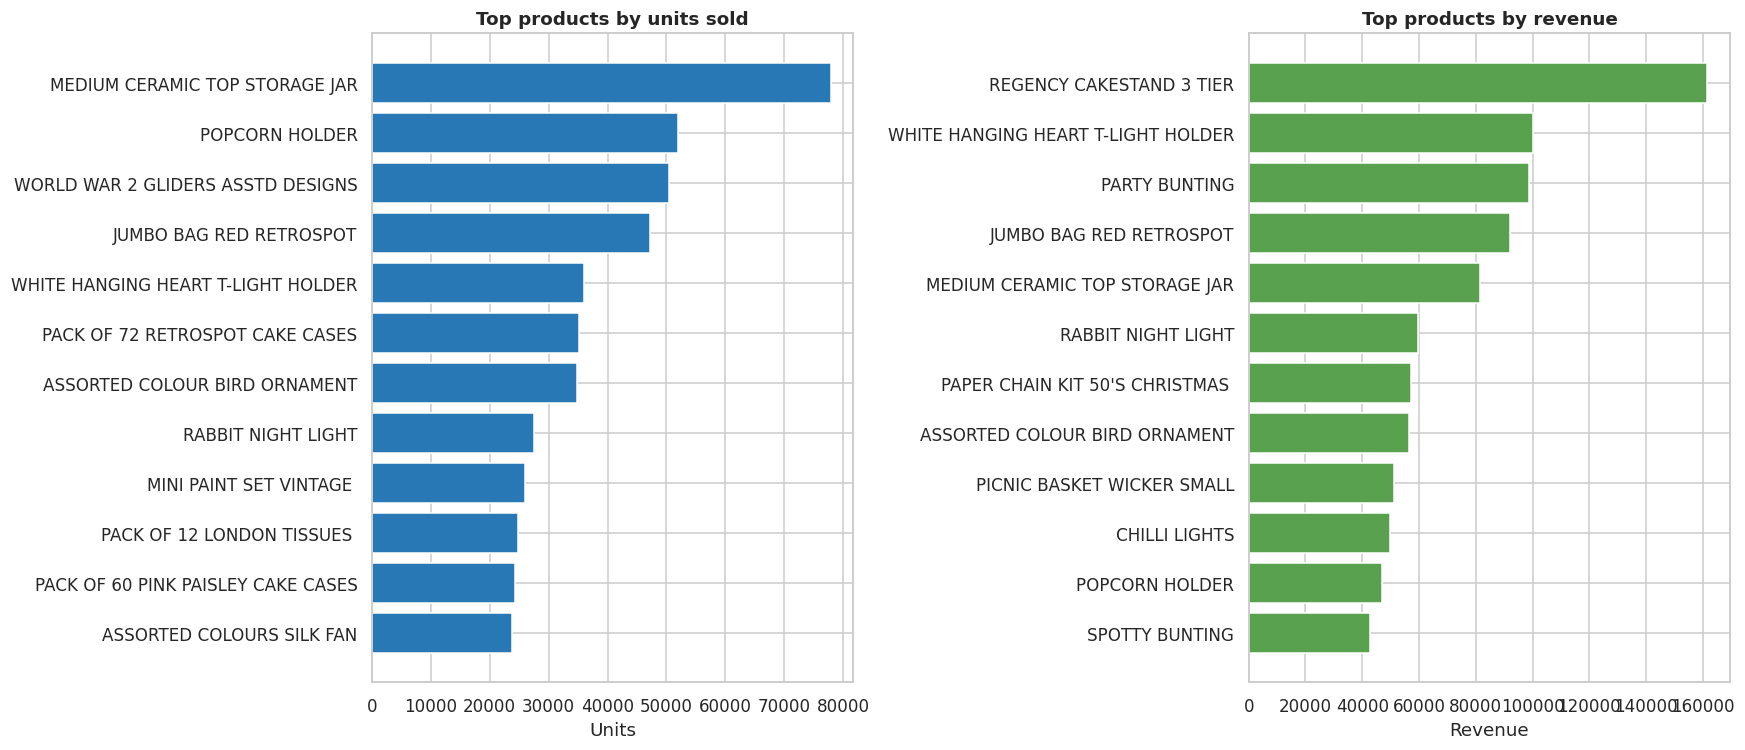

In [12]:
product_summary = (
    analysis_transactions.loc[analysis_transactions['StockCode'].isin(eligible_products)]
    .groupby('StockCode')
    .agg(
        UnitsSold=('Quantity', 'sum'),
        Revenue=('Revenue', 'sum'),
        SellingWeeks=('WeekStart', 'nunique'),
        Description=('Description', lambda s: s.mode().iat[0] if not s.mode().empty else 'Unknown'),
    )
    .sort_values('UnitsSold', ascending=False)
)

top_units = product_summary.head(12).sort_values('UnitsSold')
top_revenue = product_summary.sort_values('Revenue', ascending=False).head(12).sort_values('Revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top_units['Description'].str.slice(0, 35), top_units['UnitsSold'], color='#2878B5')
axes[0].set_title('Top products by units sold')
axes[0].set_xlabel('Units')
axes[1].barh(top_revenue['Description'].str.slice(0, 35), top_revenue['Revenue'], color='#59A14F')
axes[1].set_title('Top products by revenue')
axes[1].set_xlabel('Revenue')
plt.tight_layout()
plt.show()

display(product_summary.head(10))
display(product_summary.sort_values('Revenue', ascending=False).head(10))


Top 25.4% of eligible products account for 80% of units sold.


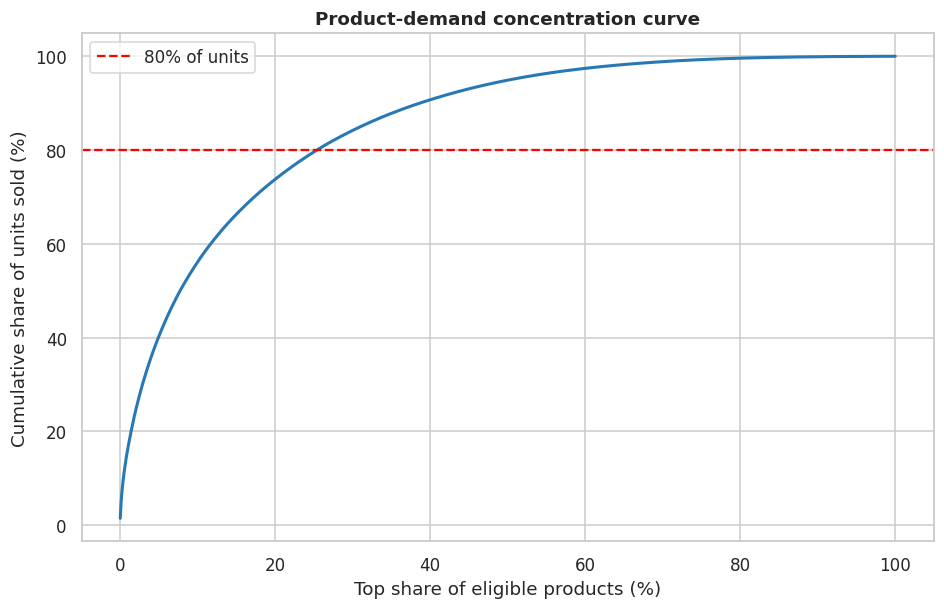

In [13]:
ranked_units = product_summary['UnitsSold'].sort_values(ascending=False)
cumulative_share = ranked_units.cumsum().div(ranked_units.sum())
product_share = np.arange(1, len(cumulative_share) + 1) / len(cumulative_share)

plt.figure(figsize=(10, 6))
plt.plot(product_share * 100, cumulative_share * 100, color='#2878B5', linewidth=2)
plt.axhline(80, color='red', linestyle='--', label='80% of units')
plt.xlabel('Top share of eligible products (%)')
plt.ylabel('Cumulative share of units sold (%)')
plt.title('Product-demand concentration curve')
plt.legend()
plt.show()

share_needed_for_80 = product_share[np.argmax(cumulative_share.to_numpy() >= 0.80)]
print(f'Top {share_needed_for_80:.1%} of eligible products account for 80% of units sold.')


**Interpretation.** The products leading by units are not identical to those leading by revenue, so demand forecasts and financial planning answer different questions. Strong concentration supports reporting model performance separately for high-, medium-, and low-volume products rather than allowing the largest sellers to dominate every metric.


           Country  UnitsSold      Revenue  Orders  RevenueSharePct
36  United Kingdom    4335318 8,110,507.94   17048            84.57
24     Netherlands     192204   271,983.72      89             2.84
10            EIRE     141155   267,407.70     272             2.79
14         Germany     112998   196,976.67     423             2.05
13          France     108022   178,820.45     370             1.86
0        Australia      83783   137,745.56      55             1.44
31           Spain      27051    54,798.35      85             0.57
33     Switzerland      30407    52,842.20      49             0.55
20           Japan      25820    37,096.29      18             0.39
32          Sweden      35997    36,590.83      33             0.38

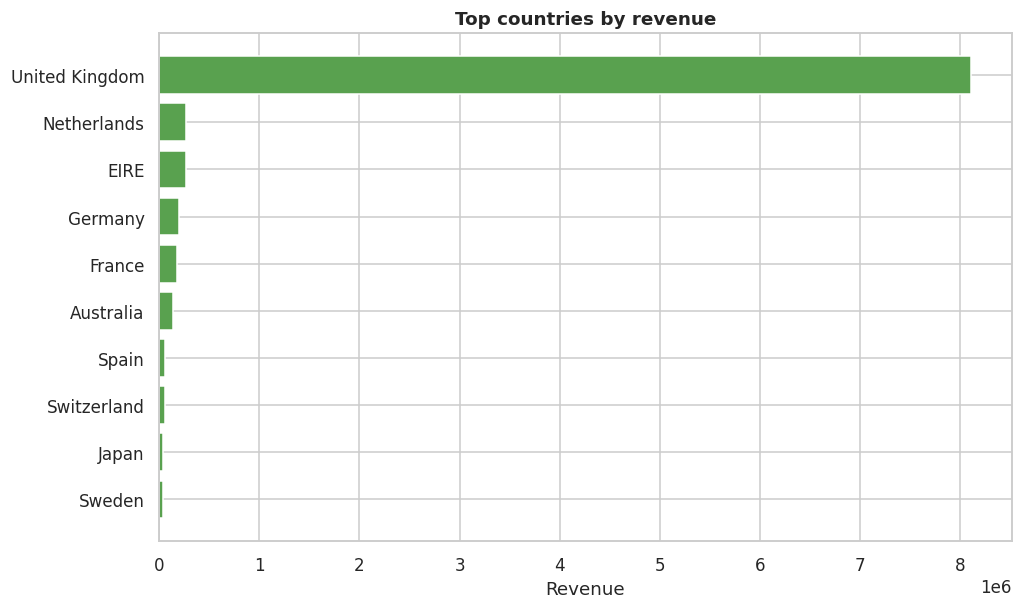

In [14]:
country_summary = (
    analysis_transactions.groupby('Country', as_index=False)
    .agg(UnitsSold=('Quantity', 'sum'), Revenue=('Revenue', 'sum'), Orders=('InvoiceNo', 'nunique'))
    .sort_values('Revenue', ascending=False)
)
country_summary['RevenueSharePct'] = country_summary['Revenue'].div(country_summary['Revenue'].sum()).mul(100)

top_countries = country_summary.head(10).sort_values('Revenue')
plt.figure(figsize=(10, 6))
plt.barh(top_countries['Country'], top_countries['Revenue'], color='#59A14F')
plt.title('Top countries by revenue')
plt.xlabel('Revenue')
plt.show()
display(country_summary.head(10))


**Interpretation.** The United Kingdom dominates revenue and units, but all countries draw inventory from the same retailer. Country is valuable for descriptive segmentation; a future regional model would need sufficient history within each market and a clear fulfillment-location definition.


## 9. Relationships with weekly demand

Median price and weekly units have a monotonic relationship, but this is observational: products differ in category, popularity, promotions, and lifecycle. Same-week revenue and transaction count are consequences of demand and therefore cannot be forecasting features.


Spearman rho = -0.380
Two-sided p-value = 0.000e+00


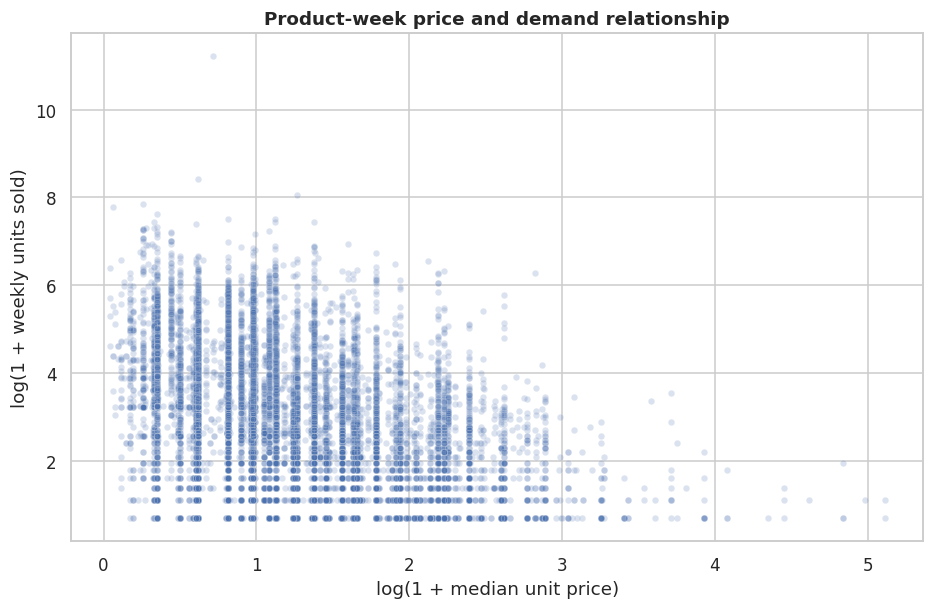

In [15]:
price_demand = observed_weekly.dropna(subset=['MedianUnitPrice', 'UnitsSold']).copy()
spearman_rho, spearman_p = stats.spearmanr(price_demand['MedianUnitPrice'], price_demand['UnitsSold'])

plot_sample = price_demand.sample(min(12_000, len(price_demand)), random_state=RANDOM_STATE)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample,
    x=np.log1p(plot_sample['MedianUnitPrice']),
    y=np.log1p(plot_sample['UnitsSold']),
    alpha=0.20,
    s=18,
)
plt.xlabel('log(1 + median unit price)')
plt.ylabel('log(1 + weekly units sold)')
plt.title('Product-week price and demand relationship')
plt.show()

print(f'Spearman rho = {spearman_rho:.3f}')
print(f'Two-sided p-value = {spearman_p:.3e}')


**Interpretation.** Price and units have a moderate negative rank association. This does not estimate price elasticity because prices and products were not randomly assigned. If price is used later, only information known before the forecast week—or a lagged/planned price—can be included. Same-week median price may leak information if it is calculated from the transactions being predicted.


## 10. Inferential question: Is Q4 weekly demand different?

### Hypotheses

- **Null hypothesis:** For products with adequate exposure in both periods, the median within-product difference between mean Q4 weekly demand and mean non-Q4 weekly demand is zero.
- **Alternative hypothesis:** The median paired difference is not zero.

The product is the unit of analysis. A paired Wilcoxon signed-rank test is used because weekly demand is highly skewed and the paired differences are not plausibly normal. Products must have at least four panel weeks in both periods. This is an exploratory association test, not a causal estimate of the Q4 effect.


Wilcoxon two-sided p-value: 1.303e-23


                                                     value
paired products                                   3,082.00
median non-Q4 mean weekly units                      11.35
median Q4 mean weekly units                          12.55
median paired difference                              0.67
bootstrap 95% CI for median difference - low          0.54
bootstrap 95% CI for median difference - high         0.82
products with higher Q4 demand (%)                   59.83
Wilcoxon statistic                            1,874,146.50
two-sided p-value                                     0.00

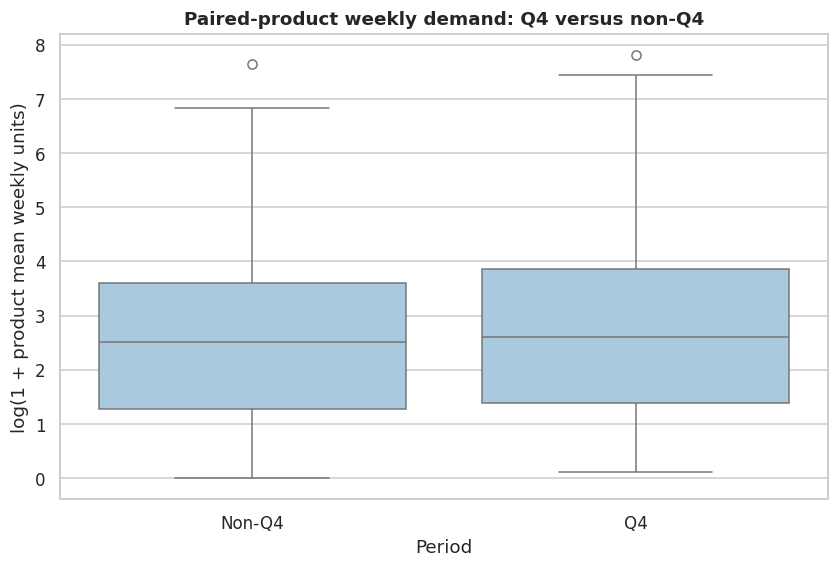

In [16]:
period_product = (
    weekly_panel.groupby(['StockCode', 'IsQ4'])
    .agg(MeanWeeklyUnits=('UnitsSold', 'mean'), Weeks=('WeekStart', 'size'))
    .reset_index()
)
paired = period_product.pivot(index='StockCode', columns='IsQ4', values=['MeanWeeklyUnits', 'Weeks']).dropna()
paired = paired.loc[(paired[('Weeks', False)] >= 4) & (paired[('Weeks', True)] >= 4)].copy()

non_q4 = paired[('MeanWeeklyUnits', False)]
q4 = paired[('MeanWeeklyUnits', True)]
paired_difference = q4 - non_q4
wilcoxon_result = stats.wilcoxon(q4, non_q4, zero_method='wilcox', alternative='two-sided')

bootstrap_medians = np.empty(2_000)
diff_values = paired_difference.to_numpy()
for i in range(len(bootstrap_medians)):
    bootstrap_medians[i] = np.median(rng.choice(diff_values, size=len(diff_values), replace=True))
ci_low, ci_high = np.quantile(bootstrap_medians, [0.025, 0.975])

test_summary = pd.Series({
    'paired products': len(paired),
    'median non-Q4 mean weekly units': non_q4.median(),
    'median Q4 mean weekly units': q4.median(),
    'median paired difference': paired_difference.median(),
    'bootstrap 95% CI for median difference - low': ci_low,
    'bootstrap 95% CI for median difference - high': ci_high,
    'products with higher Q4 demand (%)': paired_difference.gt(0).mean() * 100,
    'Wilcoxon statistic': wilcoxon_result.statistic,
    'two-sided p-value': wilcoxon_result.pvalue,
})
display(test_summary.to_frame('value'))
print(f'Wilcoxon two-sided p-value: {wilcoxon_result.pvalue:.3e}')

plot_period = pd.DataFrame({'Non-Q4': non_q4, 'Q4': q4}).melt(
    var_name='Period', value_name='MeanWeeklyUnits'
)
plt.figure(figsize=(9, 5.5))
sns.boxplot(data=plot_period, x='Period', y=np.log1p(plot_period['MeanWeeklyUnits']), color='#A0CBE8')
plt.ylabel('log(1 + product mean weekly units)')
plt.title('Paired-product weekly demand: Q4 versus non-Q4')
plt.show()


**Result.** The paired test rejects the null hypothesis at the 5% level. The typical product has modestly higher weekly demand in Q4, and a majority of matched products increase. Statistical significance is helped by the large number of products; the median paired difference and its bootstrap interval are more informative about practical magnitude. The result may reflect holidays, promotions, product mix, lifecycle timing, or broader trend, and cannot isolate a causal holiday effect from a single year.


## 11. Feature selection and leakage-safe engineering

The following candidates are derived strictly within product and ordered by week. Every lag and rolling statistic is shifted so the current week's target never enters its own predictors.


In [17]:
feature_preview = weekly_panel.sort_values(['StockCode', 'WeekStart']).copy()
grouped_units = feature_preview.groupby('StockCode')['UnitsSold']

for lag in [1, 2, 4]:
    feature_preview[f'UnitsLag{lag}'] = grouped_units.shift(lag)

feature_preview['RollingMean4'] = (
    grouped_units.shift(1)
    .groupby(feature_preview['StockCode'])
    .rolling(4, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
feature_preview['WeeksSinceFirstSale'] = feature_preview.groupby('StockCode').cumcount()
feature_preview['MonthSin'] = np.sin(2 * np.pi * feature_preview['Month'] / 12)
feature_preview['MonthCos'] = np.cos(2 * np.pi * feature_preview['Month'] / 12)

display(feature_preview[
    ['StockCode', 'WeekStart', 'UnitsSold', 'UnitsLag1', 'UnitsLag2', 'UnitsLag4',
     'RollingMean4', 'WeeksSinceFirstSale', 'Month', 'Quarter', 'MonthSin', 'MonthCos']
].head(12))


   StockCode  WeekStart  UnitsSold  UnitsLag1  UnitsLag2  UnitsLag4  \
0      10002 2010-12-06     138.00        NaN        NaN        NaN   
1      10002 2010-12-13      41.00     138.00        NaN        NaN   
2      10002 2010-12-20       2.00      41.00     138.00        NaN   
3      10002 2010-12-27       0.00       2.00      41.00        NaN   
4      10002 2011-01-03      73.00       0.00       2.00     138.00   
5      10002 2011-01-10      42.00      73.00       0.00      41.00   
6      10002 2011-01-17      76.00      42.00      73.00       2.00   
7      10002 2011-01-24      17.00      76.00      42.00       0.00   
8      10002 2011-01-31     133.00      17.00      76.00      73.00   
9      10002 2011-02-07       1.00     133.00      17.00      42.00   
10     10002 2011-02-14      14.00       1.00     133.00      76.00   
11     10002 2011-02-21      36.00      14.00       1.00      17.00   

    RollingMean4  WeeksSinceFirstSale  Month  Quarter  MonthSin  MonthCos  


In [18]:
feature_plan = pd.DataFrame([
    ('UnitsLag1 / 2 / 4', 'Keep', 'Strong recent product history; shifted to prevent leakage'),
    ('RollingMean4', 'Keep', 'Smoothed recent demand; uses prior weeks only'),
    ('MonthSin / MonthCos', 'Keep', 'Cyclical annual calendar representation'),
    ('Quarter / holiday flags', 'Keep', 'Captures seasonal and event demand'),
    ('WeeksSinceFirstSale', 'Keep', 'Product-lifecycle proxy'),
    ('Lagged or planned price', 'Conditional', 'Use only if known before forecast cutoff'),
    ('Country', 'Conditional', 'Needs a defined regional forecast grain and adequate history'),
    ('Same-week Revenue', 'Exclude', 'Directly contains UnitsSold: target leakage'),
    ('Same-week Transactions', 'Exclude', 'Observed only after demand occurs: target leakage'),
    ('Description', 'Exclude initially', 'High-cardinality text; reporting label, not baseline feature'),
    ('CustomerID', 'Exclude', 'Not required for product-week warehouse demand'),
])
feature_plan.columns = ['Feature', 'Decision', 'Reason']
display(feature_plan)


                    Feature           Decision  \
0         UnitsLag1 / 2 / 4               Keep   
1              RollingMean4               Keep   
2       MonthSin / MonthCos               Keep   
3   Quarter / holiday flags               Keep   
4       WeeksSinceFirstSale               Keep   
5   Lagged or planned price        Conditional   
6                   Country        Conditional   
7         Same-week Revenue            Exclude   
8    Same-week Transactions            Exclude   
9               Description  Exclude initially   
10               CustomerID            Exclude   

                                               Reason  
0   Strong recent product history; shifted to prev...  
1       Smoothed recent demand; uses prior weeks only  
2             Cyclical annual calendar representation  
3                  Captures seasonal and event demand  
4                             Product-lifecycle proxy  
5            Use only if known before forecast cutoff  
6   Nee

## 12. Conclusions and modeling handoff

### Main findings

1. **The correct analytical grain is product-week.** Completing zero-demand weeks materially changes the target distribution and prevents upward bias.
2. **Demand is sparse, concentrated, and heavy-tailed.** A minority of products account for most units, while many product-weeks have zero or low demand.
3. **Autumn/Q4 demand is higher for the typical matched product.** The paired nonparametric test finds a statistically significant difference, but the single-year dataset cannot establish causality or stable annual seasonality.
4. **Product history should dominate the model.** Leakage-safe lags and shifted rolling means are the most defensible predictors, supported by calendar and lifecycle features.
5. **Same-week revenue and transaction counts must be excluded.** They are outcomes of the demand being forecast.

### Modeling recommendations

- Use a chronological train/validation/test split; never randomly shuffle product-week rows.
- Fit all preprocessing, caps, and hyperparameters using training data only.
- Compare XGBoost against naive baselines such as last-week demand, seasonal lag, and per-product historical mean.
- Report MAE, RMSE, and segment-level results for high-, medium-, and low-volume products.
- Evaluate zero-demand weeks separately and include prediction bias (mean forecast error) because systematic overforecasting creates overstock.
- Consider `log1p(UnitsSold)` or a count-aware objective as a sensitivity model, while converting final forecasts to non-negative units.

### Limitations

The data represent one UK-based non-store retailer over approximately one year, include no inventory-on-hand or stockout indicator, and cannot distinguish zero demand from lost sales caused by unavailable inventory. Promotions, product categories, supplier lead times, and holidays are also incomplete. Conclusions should therefore be treated as a proof of concept rather than universal small-business demand behavior.


## Data source

Chen, D. (2015). *Online Retail* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33  
License noted by the project: Creative Commons Attribution 4.0 (CC BY 4.0).
